<a href="https://colab.research.google.com/github/SadikshyaShres/Marketing-Capstone-Project/blob/main/Credit_Card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 #Step 1: Data Transformation & ETL — Transform variables
import pandas as pd
import numpy as np

#Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score,f1_score, roc_auc_score, precision_score, recall_score, classification_report

In [ ]:
##Step 2 : Data Acquisition
#loading data
df=pd.read_csv('BankChurners.csv')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [ ]:
import os
from google.colab import files

# Create the 'outputs' directory if it doesn't already exist
os.makedirs('outputs', exist_ok=True)

# Ensure the DataFrame is saved before attempting download
# This explicitly re-saves the file every time this cell is run,
# ensuring it exists for the download function.
if 'df' in globals(): # Check if df exists to avoid NameError if run standalone
    df.to_csv("outputs/bankchurners_clean.csv", index=False)
    print("Ensuring 'bankchurners_clean.csv' is saved before download.")
else:
    print("Warning: DataFrame 'df' not found. Cannot save file before download.")

files.download('outputs/bankchurners_clean.csv')

Ensuring 'bankchurners_clean.csv' is saved before download.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Step 3: Initial Data Assessment
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [ ]:
df.shape

(10127, 23)

In [ ]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


In [ ]:
# Step 6: Data Cleaning
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [ ]:
# Step 7: Initial Data Assessment
#structure check

print("Shape:", df.shape)
display(df.head(3))
display(df.info())

Shape: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

None

In [ ]:
#drop useless cloumns

df=df.copy()
df=df.iloc[:, :-2]

if "`Customer_id`" in df.columns:
    df.drop(columns="`Customer_id`", inplace=True)

print("Shape after dropping:",df.shape)
df.head()

Shape after dropping: (10127, 21)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
#tragetcreation
df["Churn"] = np.where(df["Attrition_Flag"] == "Attrited Customer", 1, 0)
df.drop(columns=["Attrition_Flag"], inplace=True)

df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.83934
1,0.16066


In [ ]:
#Step 8: Data cleaning - handling missing values
#data quality check
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

quality_missing = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
quality_missing = quality_missing[quality_missing["missing_count"] > 0]
quality_missing

,missing_count,missing_pct


In [ ]:
#duplicate rows
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)


Duplicate rows: 0


In [ ]:
#unkown categories
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols

['Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

In [ ]:
# Replace "Unknown" with NaN, then impute with mode (most frequent)
for c in cat_cols:
    df[c] = df[c].replace("Unknown", np.nan)

# Impute categorical NaNs with mode
for c in cat_cols:
    if df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

df[cat_cols].isna().sum()


,0
Gender,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0


In [ ]:

#  OUTLIER SCAN (NUMERIC)

num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove("Churn")

df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


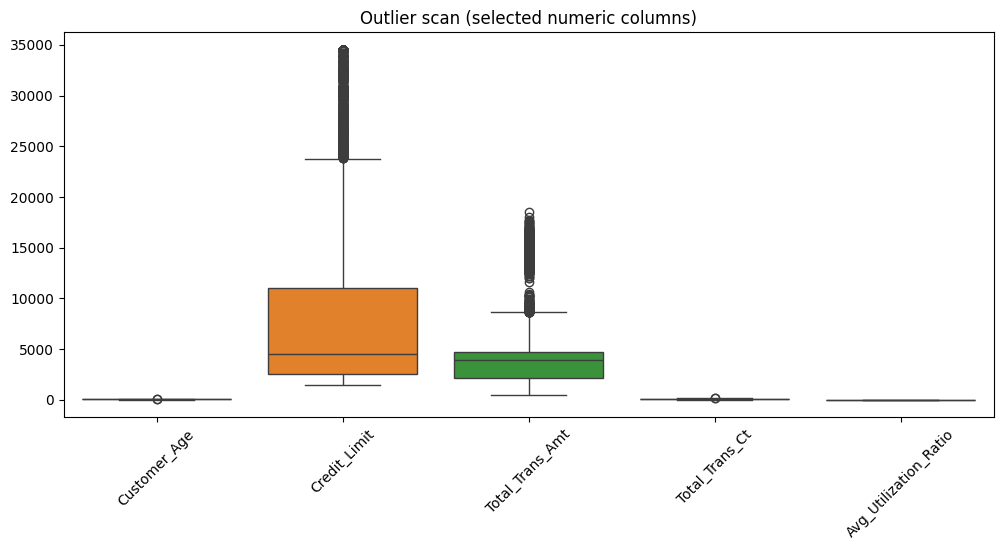

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplots for a few important numeric columns (quick view)
check_cols = ["Customer_Age", "Credit_Limit", "Total_Trans_Amt", "Total_Trans_Ct", "Avg_Utilization_Ratio"]
check_cols = [c for c in check_cols if c in df.columns]

plt.figure(figsize=(12,5))
sns.boxplot(data=df[check_cols])
plt.xticks(rotation=45)
plt.title("Outlier scan (selected numeric columns)")
plt.show()

In [ ]:
#data dictonary
data_dict = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "unique_values": [df[c].nunique() for c in df.columns],
    "example_values": [df[c].dropna().unique()[:5] for c in df.columns]
})

data_dict.head(10)


,column,dtype,unique_values,example_values
0,CLIENTNUM,int64,10127,"[768805383, 818770008, 713982108, 769911858, 7..."
1,Customer_Age,int64,45,"[45, 49, 51, 40, 44]"
2,Gender,object,2,"[M, F]"
3,Dependent_count,int64,6,"[3, 5, 4, 2, 0]"
4,Education_Level,object,6,"[High School, Graduate, Uneducated, College, P..."
5,Marital_Status,object,3,"[Married, Single, Divorced]"
6,Income_Category,object,5,"[$60K - $80K, Less than $40K, $80K - $120K, $4..."
7,Card_Category,object,4,"[Blue, Gold, Silver, Platinum]"
8,Months_on_book,int64,44,"[39, 44, 36, 34, 21]"
9,Total_Relationship_Count,int64,6,"[5, 6, 4, 3, 2]"


In [ ]:
import os
import pandas as pd

# Create the 'outputs' directory if it doesn't already exist
os.makedirs('outputs', exist_ok=True)

# data dictonary
data_dict = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "unique_values": [df[c].nunique() for c in df.columns],
    "example_values": [df[c].dropna().unique()[:5] for c in df.columns]
})

data_dict.to_csv("outputs/data_dictionary.csv", index=False)

In [ ]:
#saving clean data
df.to_csv("outputs/bankchurners_clean.csv", index=False)
print("Saved: outputs/bankchurners_clean.csv")


Saved: outputs/bankchurners_clean.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
files.download('outputs/bankchurners_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('outputs/data_dictionary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>